In [24]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet50_Weights,resnet50

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 100
LR = 5*1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_PATH = "C://Users/User/Downloads/DRIVE/training/images/*"
MASK_PATH = "C://Users/User/Downloads/DRIVE/training/mask/*"

In [3]:
class DRDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], 0)
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image = image / 255.0
        mask = mask / 255.0
        image = np.transpose(image, (2,0,1))
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return image,mask

In [25]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

In [5]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(3, 64)
        self.p1 = nn.MaxPool2d(2)
        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)
        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)
        self.d4 = DoubleConv(256, 512)
        self.p4 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.u1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.c1 = DoubleConv(1024, 512)
        self.u2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.c2 = DoubleConv(512, 256)
        self.u3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.c3 = DoubleConv(256, 128)
        self.u4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.c4 = DoubleConv(128, 64)
        self.out = nn.Conv2d(64, 1, 1)
    def forward(self, x):
        d1 = self.d1(x)
        p1 = self.p1(d1)
        d2 = self.d2(p1)
        p2 = self.p2(d2)
        d3 = self.d3(p2)
        p3 = self.p3(d3)
        d4 = self.d4(p3)
        p4 = self.p4(d4)
        bn = self.bottleneck(p4)
        u1 = self.u1(bn)
        d4 = t(u1,d4)
        u1 = torch.cat([u1, d4], dim=1)
        u1 = self.c1(u1)
        u2 = self.u2(u1)
        d3 = t(u2,d3)
        u2 = torch.cat([u2, d3], dim=1)
        u2 = self.c2(u2)
        u3 = self.u3(u2)
        d2 = t(u3,d2)
        u3 = torch.cat([u3, d2], dim=1)
        u3 = self.c3(u3)
        u4 = self.u4(u3)
        d1 = t(u4,d1)
        u4 = torch.cat([u4, d1], dim=1)
        u4 = self.c4(u4)
        out = self.out(u4)
        return out

In [6]:
def t(x1,x2):
    diffY = x2.size()[2] - x1.size()[2]
    diffX = x2.size()[3] - x1.size()[3]
    x1 = F.pad(
        x1,
        [
            diffX // 2,
            diffX - diffX // 2,
            diffY // 2,
            diffY - diffY // 2
        ]
    )
    return x1

In [7]:
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, target)
        pred = torch.sigmoid(pred)
        smooth = 1e-5
        pred = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + smooth) / (
            pred.sum() + target.sum() + smooth
        )
        return 1 - dice

In [8]:
images = sorted(glob(IMAGE_PATH))
masks = sorted(glob(MASK_PATH))

In [9]:
for i in range(len(masks)):
    masks[i] = masks[i][:-21] + "/" + masks[i][-20:]

In [10]:
for i in range(len(images)):
    images[i] = images[i][:-16] + "/" + images[i][-15:]

In [11]:
print(images)

['C://Users/User/Downloads/DRIVE/training/images/21_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/22_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/23_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/24_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/25_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/26_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/27_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/28_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/29_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/30_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/31_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/32_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/33_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/34_training.tif', 'C://Users/User/Downloads/DRIVE/training/images/35_training.tif', 'C://User

In [12]:
print(masks)

['C://Users/User/Downloads/DRIVE/training/mask/21_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/22_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/23_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/24_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/25_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/26_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/27_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/28_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/29_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/30_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/31_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/32_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/33_training_mask.gif', 'C://Users/User/Downloads/DRIVE/training/mask/34_training_mask.gif', 'C://Users/User/Downloads/DRIVE/t

In [13]:
train_x, val_x, train_y, val_y = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

In [14]:
train_x

['C://Users/User/Downloads/DRIVE/training/images/29_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/26_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/32_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/24_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/39_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/37_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/34_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/23_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/30_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/40_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/25_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/33_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/28_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/31_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/35_training.t

In [15]:
val_x

['C://Users/User/Downloads/DRIVE/training/images/21_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/38_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/36_training.tif',
 'C://Users/User/Downloads/DRIVE/training/images/22_training.tif']

In [16]:
train_dataset = DRDataset(train_x, train_y)
val_dataset = DRDataset(val_x, val_y)

In [17]:
train_dataset

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [19]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [36]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 5)
    )
model.eval()
criterion = DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [37]:
for epoch in range(2):
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader):
        print(images.shape)
        print(masks.shape)
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")

  0%|                                                                                            | 0/4 [00:00<?, ?it/s]

torch.Size([4, 3, 256, 256])
torch.Size([4, 1, 256, 256])


  0%|                                                                                            | 0/4 [00:00<?, ?it/s]


RuntimeError: The size of tensor a (20) must match the size of tensor b (262144) at non-singleton dimension 0

In [209]:
def show_prediction(image, actual_mask, predicted_mask, dice_score):
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1,3,2)
    plt.imshow(actual_mask, cmap='gray')
    plt.title("Actual Mask")
    plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(predicted_mask, cmap='gray')
    plt.title(f"Predicted Mask\nDice: {dice_score:.4f}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [218]:
def dice_coefficient(y_true, y_pred):
    smooth = 1e-5
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = (y_true * y_pred).sum()
    dice = (2.0 * intersection + smooth) / (
        y_true.sum() + y_pred.sum() + smooth
    )
    return dice

Dice Coefficient : 0.8145
Quadratic Weighted Kappa : 0.0000


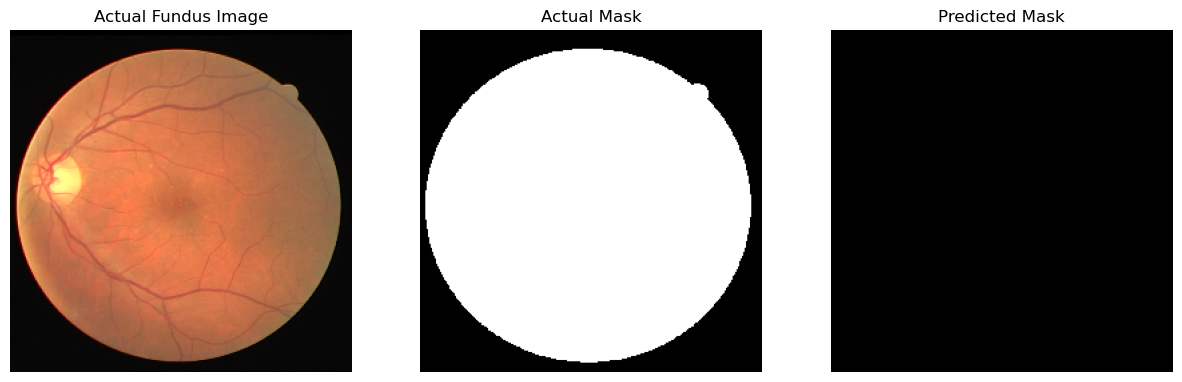

In [222]:
test_image_path = "C://Users/User/Downloads/DRIVE/training/images/21_training.tif"
test_mask_path = "C://Users/User/Downloads/DRIVE/training/mask/21_training_mask.gif"
image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(test_mask_path, 0)
image_resized = cv2.resize(image_rgb, (256,256))
mask_resized = cv2.resize(mask, (256,256))
image_input = image_resized / 255.0
image_input = np.transpose(image_input, (2,0,1))
image_tensor = torch.tensor(
    image_input,
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    pred = model(image_tensor)
    pred = torch.sigmoid(pred)
    pred = pred.cpu().numpy()[0,0]
pred_mask = (pred > 0.5).astype(np.uint8)
true_mask = (mask_resized > 0).astype(np.uint8)
dice = dice_coefficient(true_mask,pred_mask)
kappa = cohen_kappa_score(
    true_mask.flatten(),
    pred_mask.flatten(),
    weights='quadratic'
)
print(f"Dice Coefficient : {dice:.4f}")
print(f"Quadratic Weighted Kappa : {kappa:.4f}")
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(image_resized)
plt.title("Actual Fundus Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("Actual Mask")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")
plt.show()

In [ ]:
CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
class_descriptions = {
    'No_DR': 'No Diabetic Retinopathy detected. Your retina appears to be healthy.',
    'Mild': 'Mild Diabetic Retinopathy. Early stages of damage to the retina, but not critical.',
    'Moderate': 'Moderate Diabetic Retinopathy. Some visible signs of damage to the retina, requires attention.',
    'Severe': 'Severe Diabetic Retinopathy. Significant damage to the retina, may require medical intervention.',
    'Proliferate_DR': 'Proliferative Diabetic Retinopathy. The most severe form of diabetic retinopathy, requiring immediate treatment.'
}
img_path = ""
def predict_image(image_path, model):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
        return CLASS_NAMES[predicted.item()]
print(class_descriptions[predict_image(img_path, model)])